1. 원본 파일 'Oworld.csv' 불러오기 및 전처리 시작...
2. 샌드위치 데이 정의 및 특성 융합 수행...
-> 평일/휴일 특성 융합 완료 ('holiday_type' 생성)
3. 오버피팅 방지를 위한 불필요 피처 정리...
✨ 전처리 완료! 최종 파일이 'Oworld_final_processed_cleaned.csv'로 저장되었습니다.

4. 핵심 시각화 생성 중...


C:\Users\skdpa\AppData\Local\Temp\ipykernel_22460\3577198371.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_model, x='holiday_label', palette='Set2', ax=axes[0])
C:\Users\skdpa\AppData\Local\Temp\ipykernel_22460\3577198371.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mean_visitors, x='holiday_label', y=visitor_col, palette='Pastel1', ax=axes[1])


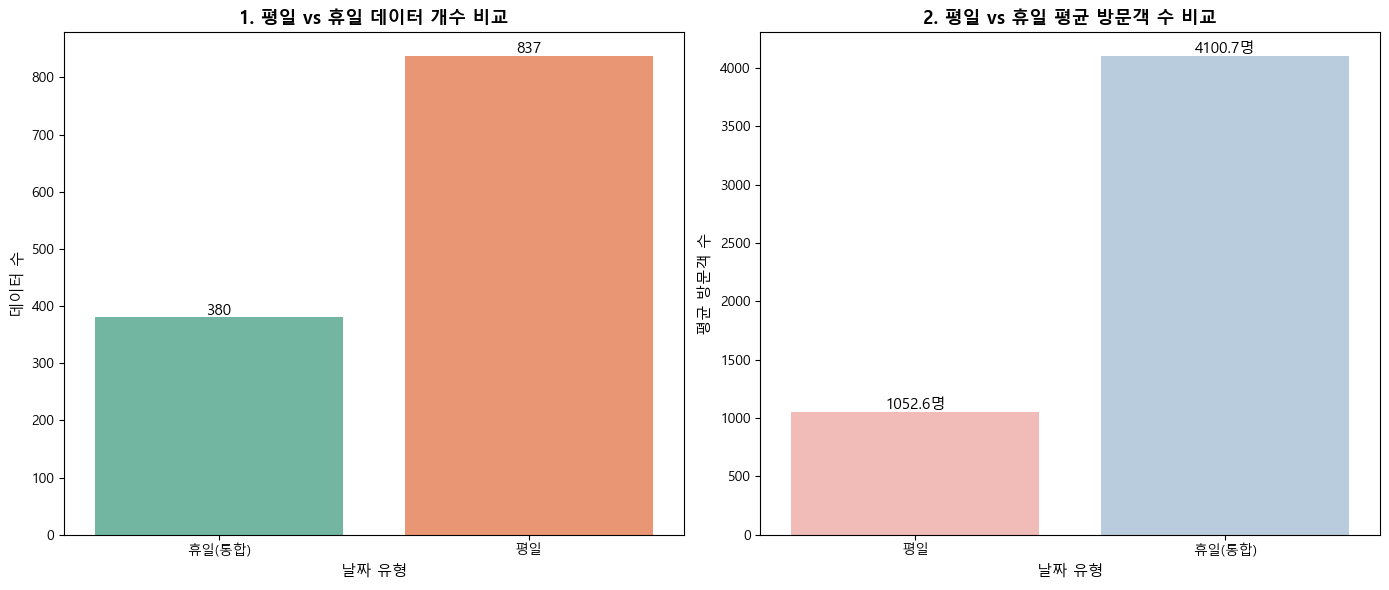

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Windows 환경 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

def process_and_visualize_oworld(input_file, output_file):
    print(f"1. 원본 파일 '{input_file}' 불러오기 및 전처리 시작...")
    try:
        df = pd.read_csv(input_file)
    except FileNotFoundError:
        print(f"[에러] '{input_file}' 파일을 찾을 수 없습니다. 현재 폴더에 원본 파일이 있는지 확인해주세요.")
        return
    
    # 날짜 컬럼 형식 변환
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date').reset_index(drop=True)

    print("2. 샌드위치 데이 정의 및 특성 융합 수행...")
    # 'dayoff' 컬럼이 있는 경우 샌드위치 데이 판별
    if 'dayoff' in df.columns:
        df['is_sandwich'] = 0
        for i in range(1, len(df) - 1):
            if df.loc[i, 'dayoff'] == 0: # 평일이면서
                if df.loc[i-1, 'dayoff'] == 1 and df.loc[i+1, 'dayoff'] == 1:
                    df.loc[i, 'is_sandwich'] = 1
    else:
        if 'is_sandwich' not in df.columns:
            df['is_sandwich'] = 0

    # 3개 컬럼(주말, 공휴일, 샌드위치 데이)을 하나로 묶어 '휴일(1)'과 '평일(0)'로 융합
    weekend_col = 'weekend' if 'weekend' in df.columns else ('is_weekend' if 'is_weekend' in df.columns else None)
    holiday_col = 'holiday' if 'holiday' in df.columns else ('is_holiday' if 'is_holiday' in df.columns else None)
    
    cond_weekend = df[weekend_col] == 1 if weekend_col and weekend_col in df.columns else False
    cond_holiday = df[holiday_col] == 1 if holiday_col and holiday_col in df.columns else False
    cond_sandwich = df['is_sandwich'] == 1
    
    # 통합 휴일 특성 생성 (휴일: 1, 평일: 0)
    df['holiday_type'] = (cond_weekend | cond_holiday | cond_sandwich).astype(int)
    print("-> 평일/휴일 특성 융합 완료 ('holiday_type' 생성)")

    print("3. 오버피팅 방지를 위한 불필요 피처 정리...")
    cols_to_drop = [weekend_col, 'is_sandwich']
    df_model = df.drop(columns=[c for c in cols_to_drop if c is not None and c in df.columns])
    
    # 최종 결과 저장
    df_model.to_csv(output_file, index=False, encoding='utf-8-sig')
    print(f"✨ 전처리 완료! 최종 파일이 '{output_file}'로 저장되었습니다.\n")

    print("4. 핵심 시각화 생성 중...")
    # 시각화를 위해 라벨 컬럼 추가
    df_model['holiday_label'] = df_model['holiday_type'].map({0: '평일', 1: '휴일(통합)'})
    
    # 방문객 수 컬럼 자동 탐색
    visitor_col = None
    for col in ['visitor', 'visitors', 'count', 'people', 'attendance']:
        if col in df_model.columns:
            visitor_col = col
            break

    # 1행 2열 서브플롯 구성 (필요 없는 3번 그래프 제거)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # [그래프 1] 데이터 개수 비교
    sns.countplot(data=df_model, x='holiday_label', palette='Set2', ax=axes[0])
    axes[0].set_title('1. 평일 vs 휴일 데이터 개수 비교', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('날짜 유형', fontsize=11)
    axes[0].set_ylabel('데이터 수', fontsize=11)
    for p in axes[0].patches:
        axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=11)

    # [그래프 2] 평균 방문객 수 비교
    if visitor_col:
        mean_visitors = df_model.groupby('holiday_label')[visitor_col].mean().reset_index()
        sns.barplot(data=mean_visitors, x='holiday_label', y=visitor_col, palette='Pastel1', ax=axes[1])
        axes[1].set_title('2. 평일 vs 휴일 평균 방문객 수 비교', fontsize=13, fontweight='bold')
        axes[1].set_xlabel('날짜 유형', fontsize=11)
        axes[1].set_ylabel('평균 방문객 수', fontsize=11)
        for p in axes[1].patches:
            axes[1].annotate(f'{p.get_height():.1f}명', (p.get_x() + p.get_width() / 2., p.get_height()), 
                             ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=11)
    else:
        axes[1].text(0.5, 0.5, "방문객 수 컬럼을 찾지 못했습니다.", ha='center', va='center', fontsize=12)
        axes[1].set_title('2. 평균 방문객 수 비교')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # 원본 파일명과 새로 저장할 파일명 지정
    process_and_visualize_oworld('Oworld.csv', 'Oworld_final_processed_cleaned.csv')